# N1 · 视频 token 化: 时空 patch (Video Tokens)

> 配套 10.5-L1 · 对合成「移动色块」视频做逐帧 vs 时空 patch, 对比 token 数 (时空压缩 tpatch 倍),
> 验证运动信号被保留。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import temporal_tokens as tt
print('temporal_tokens 就绪')

temporal_tokens 就绪


## 1. 一段「移动色块」视频 (看得见运动)

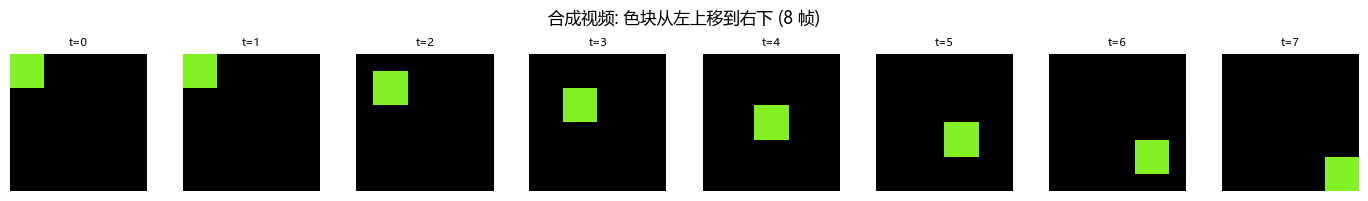

逐帧运动能量: [0.0, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806] (>0 = 有运动)


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
vid = tt.make_toy_video(T=8, size=8, seed=1)
fig, axes = plt.subplots(1, 8, figsize=(14,2))
for t, ax in enumerate(axes):
    ax.imshow(np.clip(vid[t],0,1)); ax.set_title(f't={t}', fontsize=8); ax.axis('off')
plt.suptitle('合成视频: 色块从左上移到右下 (8 帧)'); plt.tight_layout(); plt.show()
motion = tt.motion_signal(vid)
print(f"逐帧运动能量: {np.round(motion,3).tolist()} (>0 = 有运动)")

## 2. 逐帧 patch vs 时空 patch: token 数对比 (L1)

In [3]:
cmp = tt.token_count_comparison(vid, patch=2, tpatch=2)
for k, v in cmp.items():
    print(f"  {k}: {v}")
print("\n→ 时空 patch 把 token 数压缩了 (沿时间下采样), 每个 token 还含 tpatch 帧 = 编码运动。")

  逐帧 patch token 数: 128
  时空 patch token 数: 64
  压缩比: 2.0
  时间 patch 大小: 2

→ 时空 patch 把 token 数压缩了 (沿时间下采样), 每个 token 还含 tpatch 帧 = 编码运动。


## 3. tpatch (时间 patch 大小) 的权衡: 压缩 vs 时间分辨率

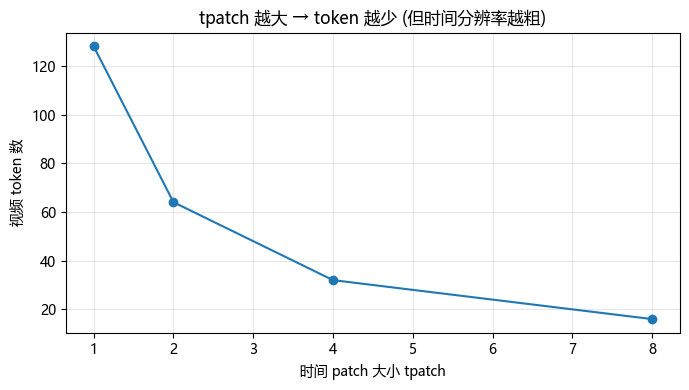

权衡 (该消融, 9.4): tpatch 大压得狠但可能丢快速动作; 小则 token 多。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
tpatches = [1, 2, 4, 8]
counts = [tt.spatiotemporal_patchify(vid, patch=2, tpatch=tp).shape[0] for tp in tpatches]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(tpatches, counts, 'o-')
ax.set_xlabel('时间 patch 大小 tpatch'); ax.set_ylabel('视频 token 数')
ax.set_title('tpatch 越大 → token 越少 (但时间分辨率越粗)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('权衡 (该消融, 9.4): tpatch 大压得狠但可能丢快速动作; 小则 token 多。')

## 4. 反思
你看清了视频 token 化的核心: **时空 patch 压缩 token + 编码运动**, 以及 tpatch 的权衡。带走:
- 视频 = 图+时间; 逐帧独立会爆炸+丢运动; 时空 patch 一举两得。
- 这接 M10.2 的上下文成本、你的 long-context 专题 (对抗时空二次方爆炸)。
下一步 N2: 音频也能 token 化 —— 波形→mel 谱→token。